# EDA Project(Online Course Market Intelligence)

## 1. Problem Definition:-

Neha is a fresher confused about which skill to invest time in. She explores online learning platforms like [Udemy](https://www.udemy.com?utm_source=chatgpt.com) and finds thousands of courses across categories such as Development, Data Science, AI, Business, and Design.

Despite similar course topics like Python, SQL, AI, Machine Learning, and Web Development:

* Some courses have millions of enrollments
* Others have better ratings but fewer students
* Some courses cost very high prices
* Others are heavily discounted

This creates confusion for Neha and many learners like her.

---

## Business Questions(Optional)

* Which category has the highest student enrollments?
* Do higher priced courses get better ratings?
* Which level dominates Udemy courses?
* Is discount percentage correlated with enrollments?
* Which instructors are most popular?
* Which skills are most in demand in 2025?
* Which courses provide the best value for money?

---

## 2. Business Problem Statement

Online learners are confused due to too many course options and unclear value-for-money differences.

The goal is to analyze Udemy course data using EDA and statistical analysis to uncover enrollment patterns, pricing trends, skill demand, and meaningful feature impacts.

---

## Project Objectives

* Identify the most in-demand skills
* Detect factors influencing course enrollments
* Analyze pricing vs ratings relationship
* Identify top-performing instructors
* Recommend valuable courses for learners
* Help freshers make data-driven learning decisions

---

## Technologies Used

* Selenium
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Statistical Analysis

---

## **Data Analytics Life Cycle**:-

Follow these Life Cycle to complete your Project

#### Business Problem and Business Understanding

                    ↓

#### Data Collection and Data Understanding

        (Selenium Web Scraping)

                    ↓

#### Data Preprocessing (Cleaning)

                    ↓

#### Exploratory Data Analysis (EDA) — Descriptive Analysis (What happened)

                    ↓

#### Advanced Statistical Analysis & Hypothesis Testing — Diagnostic Analysis (Why it happened)

                    ↓

#### Conclusion


In [1]:
import pandas as pd
import numpy as np
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
import matplotlib.pyplot as plt
import seaborn
import re
import warnings
warnings.filterwarnings('ignore')

In [2]:
import undetected_chromedriver as uc
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import time

options = uc.ChromeOptions()
options.add_argument("--start-maximized")

driver = uc.Chrome(
    version_main=148,
    options=options
)

driver.get("https://www.udemy.com/")

time.sleep(5)

time.sleep(10)

In [3]:
search_box = driver.find_element(By.XPATH,'//*[@id="search-form-autocomplete--136"]')

In [4]:
search_box.send_keys("Data Science")

In [5]:
search_box.send_keys(Keys.RETURN)

In [8]:
a = driver.find_elements(By.CLASS_NAME,"card-title-module--clipped--DPJnT")[0].text
a

'Complete Data Science,Machine Learning,DL,NLP Bootcamp'

In [9]:
course_name = [] 
for tag in driver.find_elements(By.CLASS_NAME,"card-title-module--clipped--DPJnT"):
    b = tag.text
    course_name.append(b)
course_name

['Complete Data Science,Machine Learning,DL,NLP Bootcamp',
 'The Data Science Course: Complete Data Science Bootcamp 2026',
 'Data Analytics, Data Science, & Machine Learning - All in 1',
 'Data Science & AI Masters 2026 - From Python To Gen AI',
 'Data Science + Data Analytics Career Path: 100 Days Bootcamp',
 '100 Days of Code™: The Complete Python Pro Bootcamp',
 'Python for Data Science and Machine Learning Bootcamp',
 'Complete A.I. & Machine Learning, Data Science Bootcamp',
 'Data Science and Machine Learning Fundamentals [2026]',
 'Mathematics-Basics to Advanced for Data Science And GenAI',
 'Data Science Methods and Algorithms [2026]',
 'Python for Machine Learning & Data Science Masterclass',
 '1Z0-1110-25: Oracle Cloud Infrastructure 2025 Data Science',
 'Practice Exams | Accelerated Data Science (NCA-ADS)',
 'Accelerated Data Science Exam Prep (NCA-ADS)',
 '',
 '',
 '',
 '',
 '',
 'Data Science & Machine Learning(Theory+Projects)A-Z 90 HOURS',
 'Python Data Science: Data Pr

## EXtracting Course Author names using class name 

In [11]:
a = driver.find_elements(By.CLASS_NAME,"card-authors-module--authors--zIW0Y")[0].text
a

'Instructors:\nKrish Naik, KRISHAI Technologies Private Limited'

In [44]:
author = [] 
for tag in driver.find_elements(By.CLASS_NAME,"card-authors-module--authors--zIW0Y"):
    b = tag.text
    c = re.search(r'Instructor[s]?:\s*\n?([^,\n]+)',b)
    author.append(c.group(1) if c else None)
author

['Krish Naik',
 '365 Careers',
 'Analytix AI',
 'Dr. Satyajit Pattnaik',
 "Shahriar's Analytical Academy",
 'Dr. Angela Yu',
 'Jose Portilla',
 'Andrei Neagoie',
 'Henrik Johansson',
 'Krish Naik',
 'Henrik Johansson',
 'Jose Portilla',
 'Shilpi Jain',
 'Doron Shamo',
 'ITCertify Zone',
 None,
 None,
 None,
 None,
 None,
 'AI Sciences',
 'Maven Analytics • 1',
 'School of AI',
 'Krish Naik',
 'Shan Singh | 300',
 'Jitesh Khurkhuriya',
 'Nikolai Schuler',
 'Kirill Eremenko',
 'Sundog Education by Frank Kane',
 'Henrik Johansson',
 'Sandeep Kumar Mathur',
 'Maven Analytics • 1']

## Extracting rating out of 5 using class name 

In [17]:
a = driver.find_elements(By.CLASS_NAME,"vertical-card-module--primary-bottom--1YAdN")[0].text
a

'Bestseller\nRating: 4.5 out of 5\n4.5\n25,415 ratings\n99 total hours\n429 lectures\nAll Levels\nCurrent price\n₹499.00\nOriginal Price\n₹3,449.00\nAdd to cart'

In [43]:
ratings_out_of_5 = [] 
for tag in driver.find_elements(By.CLASS_NAME,"vertical-card-module--primary-bottom--1YAdN"):
    b = tag.text
    c = re.search(r'Rating:\s*([\d.]+)',b)
    ratings_out_of_5.append(c.group(1) if c else None)
ratings_out_of_5

['4.5',
 '4.6',
 '4.5',
 '4.4',
 '4.5',
 '4.7',
 '4.6',
 '4.6',
 '4.8',
 '4.6',
 '4.9',
 '4.7',
 '0.0',
 '0.0',
 '0.0',
 None,
 None,
 None,
 None,
 None,
 '4.5',
 '4.7',
 '4.2',
 '4.5',
 '4.5',
 '4.6',
 '4.5',
 '4.3',
 '4.6',
 '4.7',
 '4.7',
 '4.9']

## Extracting ratings count using class name 

In [22]:
a = driver.find_elements(By.CLASS_NAME,"vertical-card-module--primary-bottom--1YAdN")[0].text
a

'Bestseller\nRating: 4.5 out of 5\n4.5\n25,415 ratings\n99 total hours\n429 lectures\nAll Levels\nCurrent price\n₹499.00\nOriginal Price\n₹3,449.00\nAdd to cart'

In [45]:
ratings_count = [] 
for tag in driver.find_elements(By.CLASS_NAME,"vertical-card-module--primary-bottom--1YAdN"):
    b = tag.text
    c = re.search(r'([\d,]+)\s*ratings',b)
    ratings_count.append(c.group(1) if c else None)
ratings_count

['25,415',
 '160,986',
 '4,632',
 '2,443',
 '612',
 '424,359',
 '158,710',
 '30,415',
 '1,530',
 '4,018',
 '1,085',
 '18,705',
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 '999',
 '2,016',
 '746',
 '4,013',
 '1,547',
 '3,630',
 '3,008',
 '34,852',
 '36,637',
 '465',
 '628',
 '405']

## Extracting total hours using class name 

In [25]:
a = driver.find_elements(By.CLASS_NAME,"vertical-card-module--primary-bottom--1YAdN")[0].text
a

'Bestseller\nRating: 4.5 out of 5\n4.5\n25,415 ratings\n99 total hours\n429 lectures\nAll Levels\nCurrent price\n₹499.00\nOriginal Price\n₹3,449.00\nAdd to cart'

In [46]:
total_hours = [] 
for tag in driver.find_elements(By.CLASS_NAME,"vertical-card-module--primary-bottom--1YAdN"):
    b = tag.text
    c = re.search(r'([\d.]+)\s*total hours',b)
    total_hours.append(c.group(1) if c else None)
total_hours

['99',
 '32',
 '66.5',
 '108.5',
 '48.5',
 '57',
 '25',
 '44',
 '58.5',
 '23',
 '50.5',
 '44',
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 '94',
 '8.5',
 '48.5',
 '51',
 '16.5',
 '26',
 '11.5',
 '21',
 '21',
 '22',
 '23.5',
 '17']

## Extracting lectures_count using class name

In [69]:
lectures_count = []

for tag in driver.find_elements(By.CLASS_NAME, "vertical-card-module--primary-bottom--1YAdN"):

    b = tag.text

    c = re.search(r'(\d+)\s*lecture[s]?', b, re.IGNORECASE)

    lectures_count.append(int(c.group(1)) if c else 0)

print(lectures_count)

[10, 35, 23, 20, 0, 0, 0, 0, 0, 0, 0, 0, 33, 279, 31, 75, 44, 30, 28, 63, 11, 13, 33, 27, 31, 64, 57, 42, 10, 0, 75, 0]


## Extracting level using class name

In [48]:
level = [] 
for tag in driver.find_elements(By.CLASS_NAME,"vertical-card-module--primary-bottom--1YAdN"):
    b = tag.text
    c = re.search(r'(All Levels|Beginner|Expert|Intermediate)',b)
    level.append(c.group(1) if c else None)
level

['All Levels',
 'All Levels',
 'All Levels',
 'All Levels',
 'All Levels',
 'All Levels',
 'All Levels',
 'All Levels',
 'All Levels',
 'All Levels',
 'All Levels',
 'All Levels',
 'All Levels',
 'All Levels',
 None,
 None,
 None,
 None,
 None,
 None,
 'All Levels',
 'All Levels',
 'Beginner',
 'All Levels',
 'All Levels',
 'All Levels',
 'Beginner',
 'All Levels',
 'All Levels',
 'All Levels',
 'Expert',
 'All Levels']

## Extracting Current_price 

In [50]:
current_price = [] 
for tag in driver.find_elements(By.CLASS_NAME,"vertical-card-module--primary-bottom--1YAdN"):
    b = tag.text
    c = re.search(r'Current price\s*₹([\d,]+\.?\d*)',b)
    current_price.append(c.group(1) if c else None)
current_price

['499.00',
 '509.00',
 '459.00',
 '459.00',
 '469.00',
 '459.00',
 '579.00',
 '509.00',
 '569.00',
 '469.00',
 '509.00',
 '609.00',
 '449.00',
 '449.00',
 '449.00',
 None,
 None,
 None,
 None,
 None,
 '629.00',
 '539.00',
 '489.00',
 '459.00',
 '599.00',
 '579.00',
 '639.00',
 '569.00',
 '649.00',
 '449.00',
 '589.00',
 '529.00']

## Extracting original_price

In [51]:
original_price = [] 
for tag in driver.find_elements(By.CLASS_NAME,"vertical-card-module--primary-bottom--1YAdN"):
    b = tag.text
    c = re.search(r'Original Price\s*₹([\d,]+\.?\d*)',b)
    original_price.append(c.group(1) if c else None)
original_price

['3,449.00',
 '3,549.00',
 '799.00',
 '3,109.00',
 '799.00',
 '3,199.00',
 '4,019.00',
 '3,549.00',
 '879.00',
 '799.00',
 '2,789.00',
 '4,229.00',
 '799.00',
 '799.00',
 '799.00',
 None,
 None,
 None,
 None,
 None,
 '3,599.00',
 '829.00',
 '3,089.00',
 '3,179.00',
 '4,139.00',
 '4,019.00',
 '4,429.00',
 '3,929.00',
 '4,469.00',
 '799.00',
 '4,089.00',
 '3,349.00']

## Extracting add_to_cart

In [52]:

add_to_cart = []

for tag in driver.find_elements(By.CLASS_NAME, "vertical-card-module--primary-bottom--1YAdN"):
    b = tag.text

    c = "Yes" if re.findall(r'Add to cart', b) else "No"

    add_to_cart.append(c)

print(add_to_cart)

['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes']


In [70]:
len(course_name) , len(author) , len(ratings_out_of_5) , len(ratings_count) , len(total_hours), len(lectures_count) , len(level) , len(current_price) , len(original_price) , len(add_to_cart)

(5440, 6255, 6320, 6336, 6336, 32, 6336, 6336, 6336, 6336)

In [73]:
from itertools import zip_longest

data=list(zip_longest(course_name,author,ratings_out_of_5,ratings_count,total_hours,lectures_count,level,current_price,original_price,add_to_cart))
data

[('Complete Data Science,Machine Learning,DL,NLP Bootcamp',
  'Krish Naik',
  '4.5',
  '25,415',
  '99',
  10,
  'All Levels',
  '499.00',
  '3,449.00',
  'Yes'),
 ('The Data Science Course: Complete Data Science Bootcamp 2026',
  '365 Careers',
  '4.6',
  '160,986',
  '32',
  35,
  'All Levels',
  '509.00',
  '3,549.00',
  'Yes'),
 ('Data Analytics, Data Science, & Machine Learning - All in 1',
  'Analytix AI',
  '4.5',
  '4,632',
  '66.5',
  23,
  'All Levels',
  '459.00',
  '799.00',
  'Yes'),
 ('Data Science & AI Masters 2026 - From Python To Gen AI',
  'Dr. Satyajit Pattnaik',
  '4.4',
  '2,443',
  '108.5',
  20,
  'All Levels',
  '459.00',
  '3,109.00',
  'Yes'),
 ('Data Science + Data Analytics Career Path: 100 Days Bootcamp',
  'Doron Shamo',
  '0.0',
  None,
  None,
  0,
  'All Levels',
  '449.00',
  '799.00',
  'No'),
 ('100 Days of Code™: The Complete Python Pro Bootcamp',
  'Shilpi Jain',
  '0.0',
  None,
  None,
  0,
  'All Levels',
  '449.00',
  '799.00',
  'No'),
 ('Pyth

In [74]:
df=pd.DataFrame(data,columns=['Course_Name','Instructor','Ratings_Out_of_5','Ratings_Count','Course_Duration','Lectures_count','Course_level','Current_price','Orginal_price','Add_to_cart'])
df

,Course_Name,Instructor,Ratings_Out_of_5,Ratings_Count,Course_Duration,Lectures_count,Course_level,Current_price,Orginal_price,Add_to_cart
0,"Complete Data Science,Machine Learning,DL,NLP ...",Krish Naik,4.5,"25,415",99,10.0,All Levels,499.00,"3,449.00",Yes
1,The Data Science Course: Complete Data Science...,365 Careers,4.6,"160,986",32,35.0,All Levels,509.00,"3,549.00",Yes
2,"Data Analytics, Data Science, & Machine Learni...",Analytix AI,4.5,"4,632",66.5,23.0,All Levels,459.00,799.00,Yes
3,Data Science & AI Masters 2026 - From Python T...,Dr. Satyajit Pattnaik,4.4,"2,443",108.5,20.0,All Levels,459.00,"3,109.00",Yes
4,Data Science + Data Analytics Career Path: 100...,Doron Shamo,0.0,None,None,0.0,All Levels,449.00,799.00,No
...,...,...,...,...,...,...,...,...,...,...
6331,None,None,None,100,3,NaN,All Levels,459.00,"2,359.00",Yes
6332,None,None,None,10,0.5,NaN,Beginner,449.00,799.00,Yes
6333,None,None,None,13,None,NaN,All Levels,449.00,799.00,Yes
6334,None,None,None,50,13,NaN,All Levels,449.00,799.00,Yes


In [75]:
course_name = [] 
author = []
ratings_out_of_5 = [] 
ratings_count = [] 
total_hours = [] 
lectures_hours = []
level = [] 
current_price = [] 
original_price = [] 
add_to_cart = []

for i in range(1,140):
    url = f'https://www.udemy.com/courses/search/?p={i}&q=Data+Science&src=ukw'
    driver.get(url)

    for tag in driver.find_elements(By.CLASS_NAME,"card-title-module--clipped--DPJnT"):
        b = tag.text
        course_name.append(b)

    for tag in driver.find_elements(By.CLASS_NAME,"card-authors-module--authors--zIW0Y"):
        b = tag.text
        c = re.search(r'Instructor[s]?:\s*\n?([^,\n]+)',b)
        author.append(c.group(1) if c else None)

    for tag in driver.find_elements(By.CLASS_NAME,"vertical-card-module--primary-bottom--1YAdN"):
        b = tag.text
        c = re.search(r'Rating:\s*([\d.]+)',b)
        ratings_out_of_5.append(c.group(1) if c else None)

    for tag in driver.find_elements(By.CLASS_NAME,"vertical-card-module--primary-bottom--1YAdN"):
        b = tag.text
        c = re.search(r'([\d,]+)\s*ratings',b)
        ratings_count.append(c.group(1) if c else None)

    for tag in driver.find_elements(By.CLASS_NAME,"vertical-card-module--primary-bottom--1YAdN"):
        b = tag.text
        c = re.search(r'([\d.]+)\s*total hours',b)
        total_hours.append(c.group(1) if c else None)

    for tag in driver.find_elements(By.CLASS_NAME,"vertical-card-module--primary-bottom--1YAdN"):
        b = tag.text
        c = re.search(r'(\d+)\s*lectures',b)
        lectures_count.append(c.group(1) if c else None)

    for tag in driver.find_elements(By.CLASS_NAME,"vertical-card-module--primary-bottom--1YAdN"):
        b = tag.text
        c = re.search(r'(All Levels|Beginner|Expert|Intermediate)',b)
        level.append(c.group(1) if c else None)

    for tag in driver.find_elements(By.CLASS_NAME,"vertical-card-module--primary-bottom--1YAdN"):
        b = tag.text
        c = re.search(r'Current price\s*₹([\d,]+\.?\d*)',b)
        current_price.append(c.group(1) if c else None)

    for tag in driver.find_elements(By.CLASS_NAME,"vertical-card-module--primary-bottom--1YAdN"):
        b = tag.text
        c = re.search(r'Original Price\s*₹([\d,]+\.?\d*)',b)
        original_price.append(c.group(1) if c else None)

    for tag in driver.find_elements(By.CLASS_NAME, "vertical-card-module--primary-bottom--1YAdN"):
        b = tag.text

        c = "Yes" if re.findall(r'Add to cart', b) else "No"

        add_to_cart.append(c)

        
    
    print(f'Page {i} scraped')

Page 1 scraped
Page 2 scraped
Page 3 scraped
Page 4 scraped
Page 5 scraped
Page 6 scraped
Page 7 scraped
Page 8 scraped
Page 9 scraped
Page 10 scraped
Page 11 scraped
Page 12 scraped
Page 13 scraped
Page 14 scraped
Page 15 scraped
Page 16 scraped
Page 17 scraped
Page 18 scraped
Page 19 scraped
Page 20 scraped
Page 21 scraped
Page 22 scraped
Page 23 scraped
Page 24 scraped
Page 25 scraped
Page 26 scraped
Page 27 scraped
Page 28 scraped
Page 29 scraped
Page 30 scraped
Page 31 scraped
Page 32 scraped
Page 33 scraped
Page 34 scraped
Page 35 scraped
Page 36 scraped
Page 37 scraped
Page 38 scraped
Page 39 scraped
Page 40 scraped
Page 41 scraped
Page 42 scraped
Page 43 scraped
Page 44 scraped
Page 45 scraped
Page 46 scraped
Page 47 scraped
Page 48 scraped
Page 49 scraped
Page 50 scraped
Page 51 scraped
Page 52 scraped
Page 53 scraped
Page 54 scraped
Page 55 scraped
Page 56 scraped
Page 57 scraped
Page 58 scraped
Page 59 scraped
Page 60 scraped
Page 61 scraped
Page 62 scraped
Page 63 scraped
P

In [78]:
data=list(zip_longest(course_name,author,ratings_out_of_5,ratings_count,total_hours,lectures_count,level,current_price,original_price,add_to_cart))
df=pd.DataFrame(data,columns=['Course_Name','Instructor','Ratings_Out_of_5','Ratings_Count','Course_Duration','Lectures_count','Course_level','Current_price','Orginal_price','Add_to_cart'])
df

,Course_Name,Instructor,Ratings_Out_of_5,Ratings_Count,Course_Duration,Lectures_count,Course_level,Current_price,Orginal_price,Add_to_cart
0,"Complete Data Science,Machine Learning,DL,NLP ...",Krish Naik,4.5,"25,439",99,10,All Levels,499.00,"3,449.00",Yes
1,The Data Science Course: Complete Data Science...,365 Careers,4.6,"160,998",32,35,All Levels,509.00,"3,549.00",Yes
2,"Data Analytics, Data Science, & Machine Learni...",Analytix AI,4.5,"4,634",66.5,23,All Levels,459.00,799.00,Yes
3,Data Science & AI Masters 2026 - From Python T...,Dr. Satyajit Pattnaik,4.4,"2,444",108.5,20,All Levels,459.00,"3,109.00",Yes
4,1Z0-1110-25: Oracle Cloud Infrastructure 2025 ...,Shilpi Jain,0.0,None,None,0,All Levels,449.00,799.00,No
...,...,...,...,...,...,...,...,...,...,...
4467,None,None,None,None,None,33,None,None,None,None
4468,None,None,None,None,None,54,None,None,None,None
4469,None,None,None,None,None,64,None,None,None,None
4470,None,None,None,None,None,31,None,None,None,None


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4472 entries, 0 to 4471
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Course_Name       4144 non-null   object
 1   Instructor        3723 non-null   object
 2   Ratings_Out_of_5  3726 non-null   object
 3   Ratings_Count     2998 non-null   object
 4   Course_Duration   2924 non-null   object
 5   Lectures_count    3173 non-null   object
 6   Course_level      3614 non-null   object
 7   Current_price     3462 non-null   object
 8   Orginal_price     1483 non-null   object
 9   Add_to_cart       4448 non-null   object
dtypes: object(10)
memory usage: 349.5+ KB


In [80]:
df.to_csv('udemy_datascraped.csv',index=False)

In [81]:
df=pd.read_csv('udemy_datascraped.csv')

In [82]:
df

,Course_Name,Instructor,Ratings_Out_of_5,Ratings_Count,Course_Duration,Lectures_count,Course_level,Current_price,Orginal_price,Add_to_cart
0,"Complete Data Science,Machine Learning,DL,NLP ...",Krish Naik,4.5,"25,439",99.0,10.0,All Levels,499.00,"3,449.00",Yes
1,The Data Science Course: Complete Data Science...,365 Careers,4.6,"160,998",32.0,35.0,All Levels,509.00,"3,549.00",Yes
2,"Data Analytics, Data Science, & Machine Learni...",Analytix AI,4.5,"4,634",66.5,23.0,All Levels,459.00,799.00,Yes
3,Data Science & AI Masters 2026 - From Python T...,Dr. Satyajit Pattnaik,4.4,"2,444",108.5,20.0,All Levels,459.00,"3,109.00",Yes
4,1Z0-1110-25: Oracle Cloud Infrastructure 2025 ...,Shilpi Jain,0.0,NaN,NaN,0.0,All Levels,449.00,799.00,No
...,...,...,...,...,...,...,...,...,...,...
4467,NaN,NaN,NaN,NaN,NaN,33.0,NaN,NaN,NaN,NaN
4468,NaN,NaN,NaN,NaN,NaN,54.0,NaN,NaN,NaN,NaN
4469,NaN,NaN,NaN,NaN,NaN,64.0,NaN,NaN,NaN,NaN
4470,NaN,NaN,NaN,NaN,NaN,31.0,NaN,NaN,NaN,NaN


## Data Cleaning 

### 1. Drop rows where Course_Name is null — it's the primary identifier. Imputing a course name makes no analytical sense. Also deduplicate on this column after cleaning.

In [83]:
df = df.dropna(subset=['Course_Name'])

In [85]:
df.shape

(3564, 10)

### 2.Fill with "Unknown" — do NOT use mode, because 1,219 unique instructors means the mode (Doron Shamo, 139 rows) would incorrectly credit him for 749 courses. "Unknown" preserves analytical integrity.

In [86]:
df['Instructor'] = df['Instructor'].fillna('Unknown') 

### 3. Safe to use mode here — only 4 levels and "All Levels" dominates (2,188 rows, 59%). Fill nulls with "All Levels".

In [87]:
df['Course_level'] = (
    df['Course_level']
    .fillna(df['Course_level'].mode()[0])
)

In [88]:
df.columns

Index(['Course_Name', 'Instructor', 'Ratings_Out_of_5', 'Ratings_Count',
       'Course_Duration', 'Lectures_count', 'Course_level', 'Current_price',
       'Orginal_price', 'Add_to_cart'],
      dtype='object')

### 4. Ratings_Count column cleaning 

In [91]:
df['Ratings_Count'] = pd.to_numeric(df['Ratings_Count'], errors='coerce')
#converting into numeric

In [92]:
df['Ratings_Count'] = df['Ratings_Count'].fillna(0)
#fill nulls with 0 — a missing rating count likely means no ratings yet, not a random value.

### Current_price cleaning 

In [93]:
# removing commas 

df['Current_price'] = (
    df['Current_price']
    .astype(str)
    .str.replace(',', '')
)

In [94]:
# converting datatype to float 

df['Current_price'] = pd.to_numeric(
    df['Current_price'],
    errors='coerce'
)

In [95]:
# Fill Nulls with Median

df['Current_price'] = (
    df['Current_price']
    .fillna(df['Current_price'].median())
)

### Original_price column cleaning 

In [97]:
# removing commas 
df['Orginal_price'] = (
    df['Orginal_price']
    .astype(str)
    .str.replace(',', '')
)

In [98]:
# changing datatype to float 

df['Orginal_price'] = pd.to_numeric(
    df['Orginal_price'],
    errors='coerce'
)

In [99]:
# Fill Original Price using Current Price that means no discount 
df['Orginal_price'] = (
    df['Orginal_price']
    .fillna(df['Current_price'])
)

## Add_to_cart column cleaning 

In [100]:
df = df.dropna(subset=['Add_to_cart'])

In [101]:
df.shape

(3564, 10)

## Rating_out_of_5 column cleaning 

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3564 entries, 0 to 4143
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Course_Name       3564 non-null   object 
 1   Instructor        3564 non-null   object 
 2   Ratings_Out_of_5  2969 non-null   float64
 3   Ratings_Count     3564 non-null   float64
 4   Course_Duration   2281 non-null   float64
 5   Lectures_count    2505 non-null   float64
 6   Course_level      3564 non-null   object 
 7   Current_price     3564 non-null   float64
 8   Orginal_price     3564 non-null   float64
 9   Add_to_cart       3564 non-null   object 
dtypes: float64(6), object(4)
memory usage: 306.3+ KB


In [103]:
df['Ratings_Out_of_5'] = (
    df['Ratings_Out_of_5']
    .fillna(df['Ratings_Out_of_5'].median())
)

## Course_duration column cleaning 

In [106]:
Q1 = df['Course_Duration'].quantile(0.25)

Q3 = df['Course_Duration'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Course_Duration'] < lower_bound) |
    (df['Course_Duration'] > upper_bound)
]

print("Number of Outliers:", outliers.shape[0])

print(df['Course_Duration'].skew())

if df['Course_Duration'].skew() > 1:
    print("Highly Right Skewed")

elif df['Course_Duration'].skew() < -1:
    print("Highly Left Skewed")

else:
    print("Moderately Skewed / Symmetric")

Number of Outliers: 211
2.987519824974694
Highly Right Skewed


In [107]:
df['Course_Duration'] = (
    df['Course_Duration']
    .fillna(df['Course_Duration'].median())
)

## lectures_count column cleaning 

In [108]:
df['Lectures_count'] = (
    df['Lectures_count']
    .fillna(df['Lectures_count'].median())
)

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3564 entries, 0 to 4143
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Course_Name       3564 non-null   object 
 1   Instructor        3564 non-null   object 
 2   Ratings_Out_of_5  3564 non-null   float64
 3   Ratings_Count     3564 non-null   float64
 4   Course_Duration   3564 non-null   float64
 5   Lectures_count    3564 non-null   float64
 6   Course_level      3564 non-null   object 
 7   Current_price     3564 non-null   float64
 8   Orginal_price     3564 non-null   float64
 9   Add_to_cart       3564 non-null   object 
dtypes: float64(6), object(4)
memory usage: 306.3+ KB


In [2]:
df.to_csv('udemy_cleaned_datascraped.csv',index=False) 

NameError: name 'df' is not defined

In [3]:
df=pd.read_csv('udemy_cleaned_datascraped.csv')

In [4]:
df

,Course_Name,Instructor,Ratings_Out_of_5,Ratings_Count,Course_Duration,Lectures_count,Course_level,Current_price,Orginal_price,Add_to_cart
0,"Complete Data Science,Machine Learning,DL,NLP ...",Krish Naik,4.5,0.0,99.0,10.0,All Levels,499.0,3449.0,Yes
1,The Data Science Course: Complete Data Science...,365 Careers,4.6,0.0,32.0,35.0,All Levels,509.0,3549.0,Yes
2,"Data Analytics, Data Science, & Machine Learni...",Analytix AI,4.5,0.0,66.5,23.0,All Levels,459.0,799.0,Yes
3,Data Science & AI Masters 2026 - From Python T...,Dr. Satyajit Pattnaik,4.4,0.0,108.5,20.0,All Levels,459.0,3109.0,Yes
4,1Z0-1110-25: Oracle Cloud Infrastructure 2025 ...,Shilpi Jain,0.0,0.0,6.5,0.0,All Levels,449.0,799.0,No
...,...,...,...,...,...,...,...,...,...,...
3559,Statistics with R - Intermediate Level,Unknown,4.3,0.0,6.5,78.0,All Levels,799.0,799.0,No
3560,Using Azure AI Document Intelligence,Qasim Shah,4.1,86.0,5.5,13.0,All Levels,1839.0,1839.0,Yes
3561,Complete Machine Learning & Artificial Intelli...,Yiqiao Yin,4.6,6.0,2.0,87.0,Intermediate,1199.0,1199.0,Yes
3562,Data Science & AI Mastery: 100 Days to Career ...,Mozn Akhourshiedah,4.5,36.0,8.5,10.0,All Levels,3889.0,3889.0,Yes


# Data visualisation 

In [5]:
import matplotlib.pyplot as plt 
import seaborn as sns

## Univariate ----> Categorical Column 

### Countplot to show course level distribution 

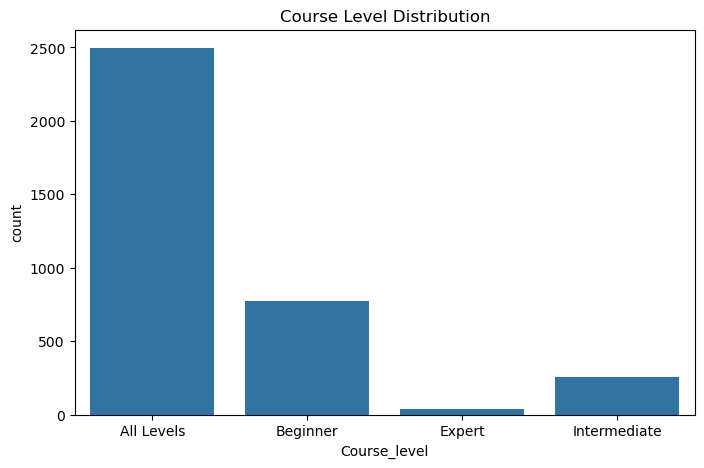

In [115]:
plt.figure(figsize=(8,5))

sns.countplot(x='Course_level', data=df)

plt.title("Course Level Distribution")

plt.show()

## Interpretation : Most Udemy courses are designed for "All Levels" learners.

### Barplot to show price distribution by course level 

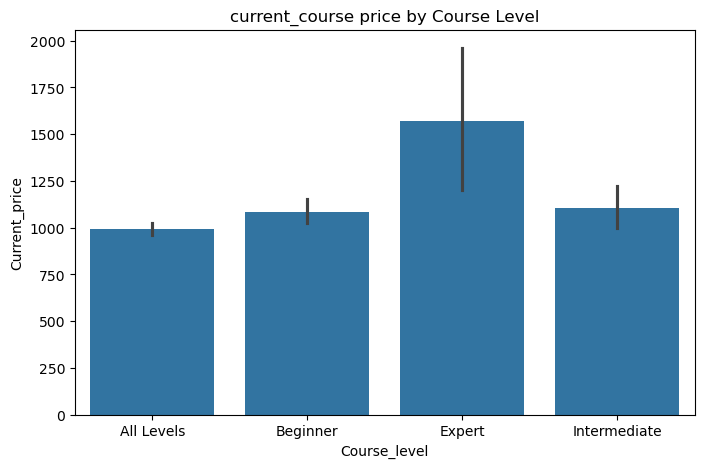

In [136]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Course_level',
    y='Current_price',
    data=df
)

plt.title("current_course price by Course Level")

plt.show()

## Interpretation : Expert courses tend to have higher average prices.

### Pie Chart to show add to cart distibution 

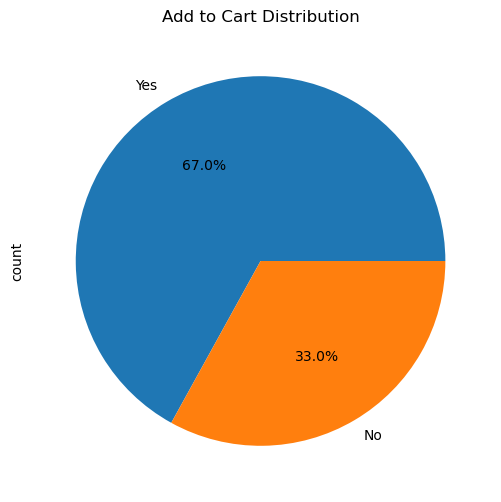

In [119]:
df['Add_to_cart'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Add to Cart Distribution")

plt.show()

## Interpretation : Most courses are available for adding to cart.

## Univarite analysis ----> Numerical columns 

### Histogram to show course duration distribution 

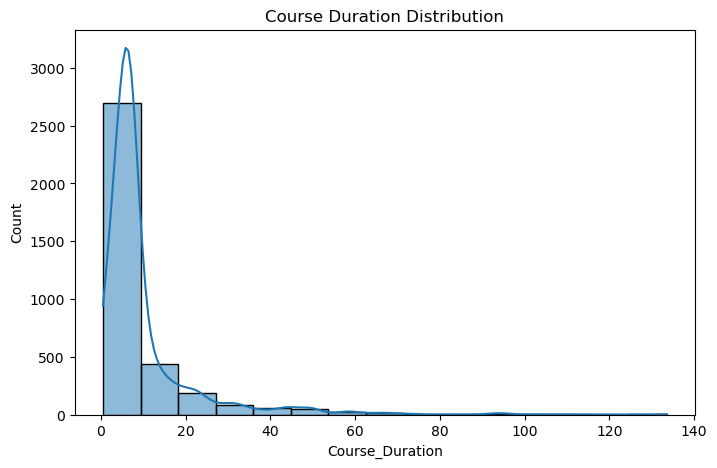

In [122]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Course_Duration'],
    bins=15,
    kde=True
)

plt.title("Course Duration Distribution")

plt.show()

## Interpretation : Most courses have shorter durations.

### Box plot to detect outliers in current price 

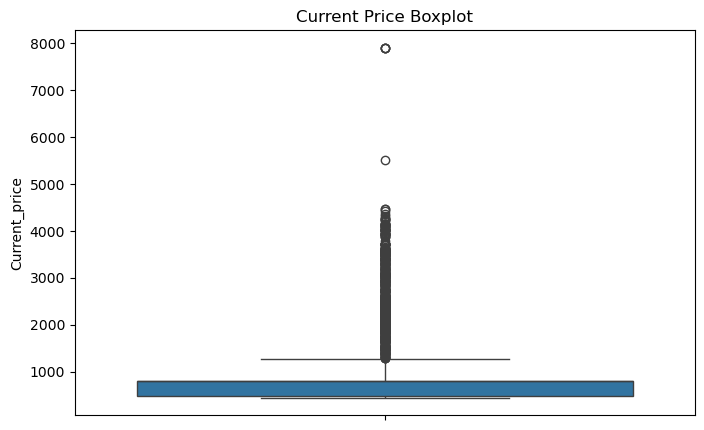

In [124]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df['Current_price'])

plt.title("Current Price Boxplot")

plt.show()

## Interpretation : Price column contains many outliers.

### KDE plot to show ratings density 

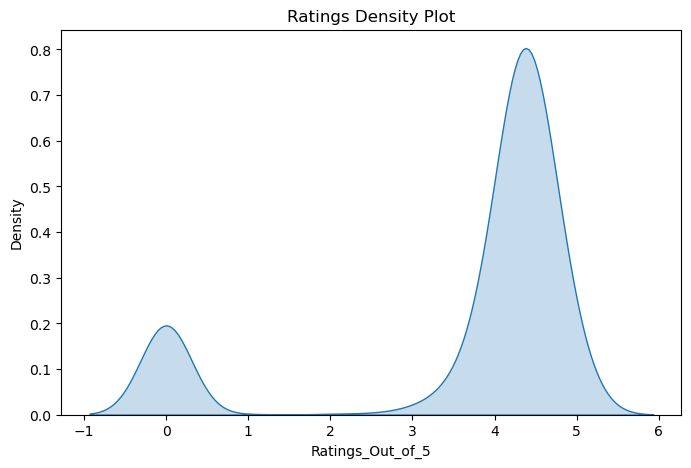

In [125]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    df['Ratings_Out_of_5'],
    fill=True
)

plt.title("Ratings Density Plot")

plt.show()

## Interpretation : Ratings are concentrated around 4–5.

## Bivariate Analysis 

### Numerical vs Numerical ---> Scatter plot to show Duration vs Ratings

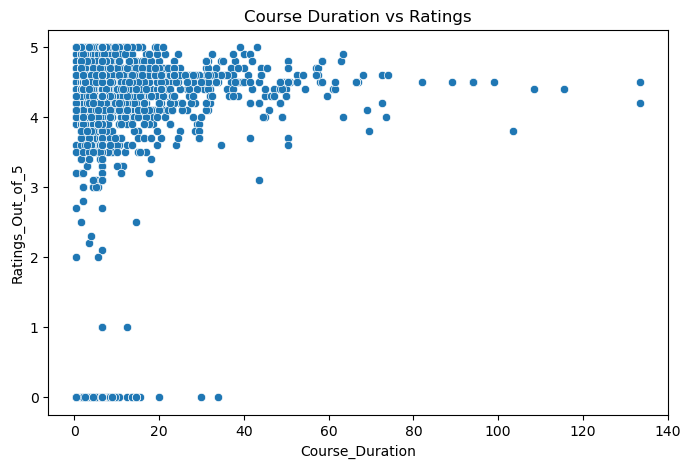

In [126]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Course_Duration',
    y='Ratings_Out_of_5',
    data=df
)

plt.title("Course Duration vs Ratings")

plt.show()

## Interpretation : There is a weak relationship between course duration and ratings.

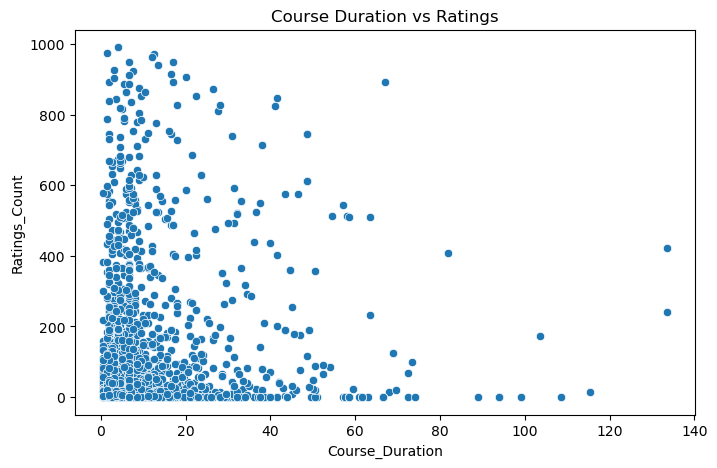

In [6]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Course_Duration',
    y='Ratings_Count',
    data=df
)

plt.title("Course Duration vs Ratings")

plt.show()

In [142]:
df.columns 

Index(['Course_Name', 'Instructor', 'Ratings_Out_of_5', 'Ratings_Count',
       'Course_Duration', 'Lectures_count', 'Course_level', 'Current_price',
       'Orginal_price', 'Add_to_cart'],
      dtype='object')

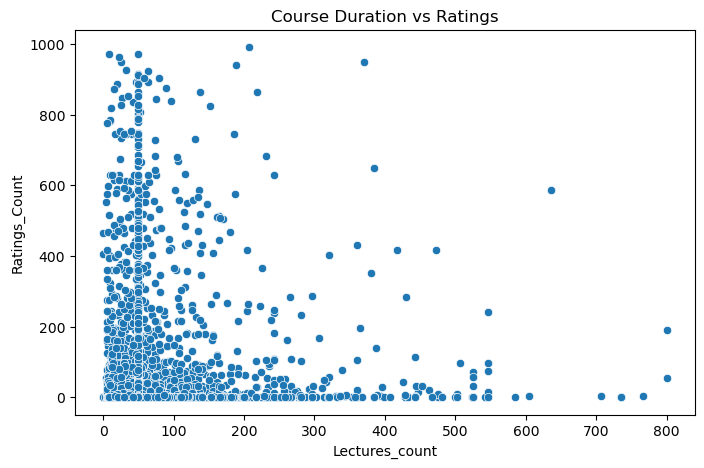

In [144]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Lectures_count',
    y='Ratings_Count',
    data=df
)

plt.title("Course Duration vs Ratings")

plt.show()

### CATEGORICAL vs NUMERICAL → BOXPLOT to show Course Level vs Current Price

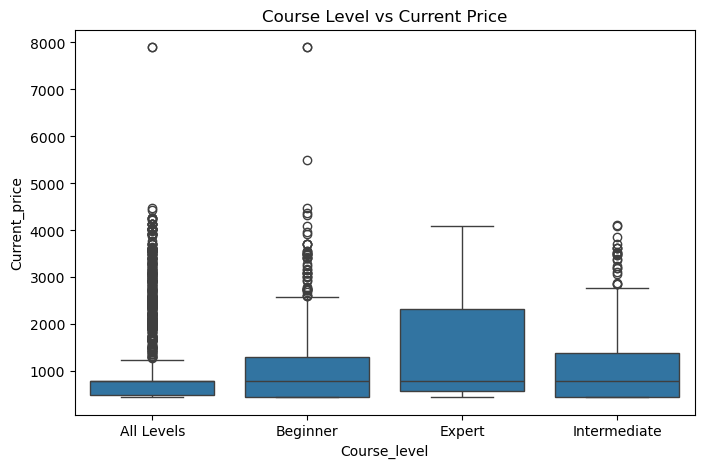

In [127]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Course_level',
    y='Current_price',
    data=df
)

plt.title("Course Level vs Current Price")

plt.show()

### Interpretation : “The pricing strategy across course levels is highly variable, with Expert courses showing greater price dispersion. Most courses remain concentrated in lower price ranges, indicating a competitive discount-based marketplace.”

### CATEGORICAL vs NUMERICAL → BARPLOT to show Instructor Average Ratings

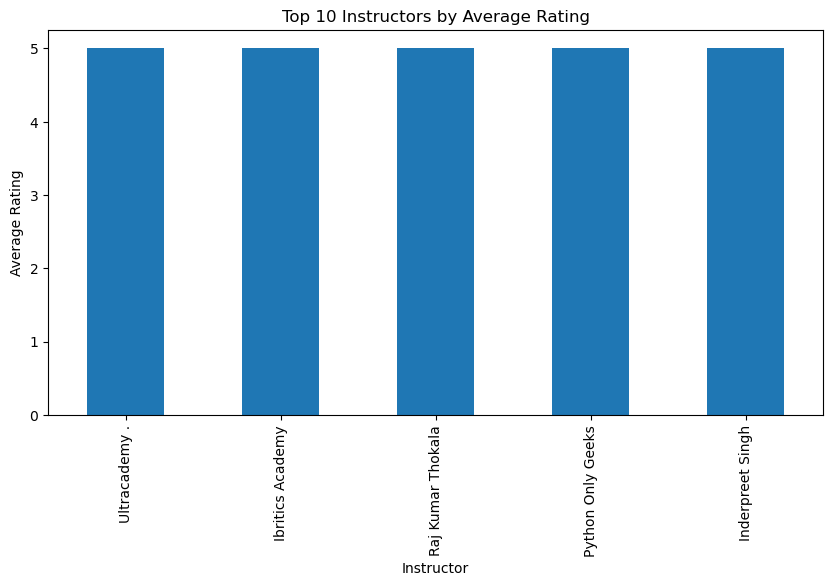

In [130]:
top_instructors = (
    df.groupby('Instructor')['Ratings_Out_of_5']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

top_instructors.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Instructors by Average Rating")

plt.ylabel("Average Rating")

plt.show()

In [9]:
df.columns

Index(['Course_Name', 'Instructor', 'Ratings_Out_of_5', 'Ratings_Count',
       'Course_Duration', 'Lectures_count', 'Course_level', 'Current_price',
       'Orginal_price', 'Add_to_cart'],
      dtype='object')

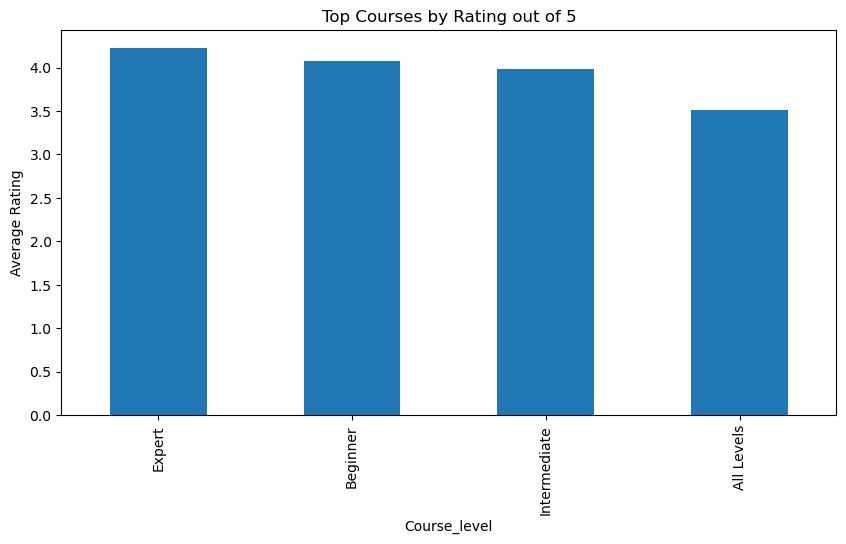

In [11]:
top_rated_course_levels = (
    df.groupby('Course_level')['Ratings_Out_of_5']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

top_rated_course_levels.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Courses by Rating out of 5")

plt.ylabel("Average Rating")

plt.show()

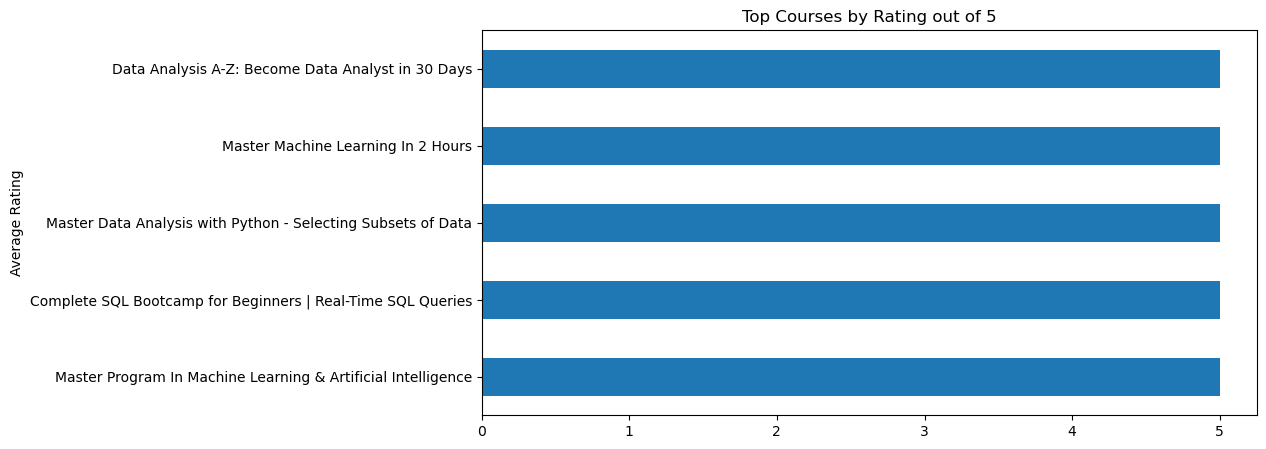

In [20]:
top_rated_courses = (
    df.groupby('Course_Name')['Ratings_Out_of_5']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

top_rated_courses.plot(
    kind='barh',
    figsize=(10,5)
)

plt.title("Top Courses by Rating out of 5")

plt.ylabel("Average Rating")

plt.show()

## categorical vs numerical --> Violin plot 

<Axes: xlabel='Course_level', ylabel='Ratings_Out_of_5'>

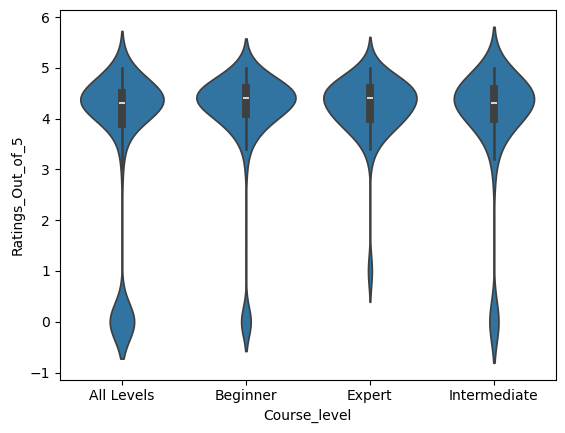

In [138]:
sns.violinplot(
    x='Course_level',
    y='Ratings_Out_of_5',
    data=df
)

## Interpretation : Most ratings across all course levels are concentrated between 4 and 5.

### CATEGORICAL vs CATEGORICAL ---> CROSS TAB to show Course Level vs Add to Cart

In [131]:
cross_tab = pd.crosstab(
    df['Course_level'],
    df['Add_to_cart']
)

print(cross_tab)

Add_to_cart     No   Yes
Course_level            
All Levels    1049  1447
Beginner       106   668
Expert           1    39
Intermediate    21   233


## Barplot for cross tab 

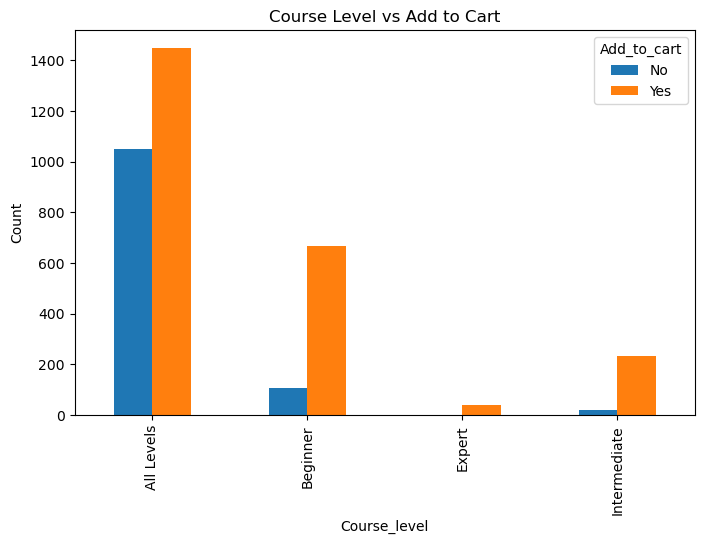

In [132]:
cross_tab.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Course Level vs Add to Cart")

plt.ylabel("Count")

plt.show()

## Interpretation : All Levels courses dominate Add_to_cart selections.

## MULTIVARIATE ANALYSIS

### HEATMAP to show Correlation Heatmap

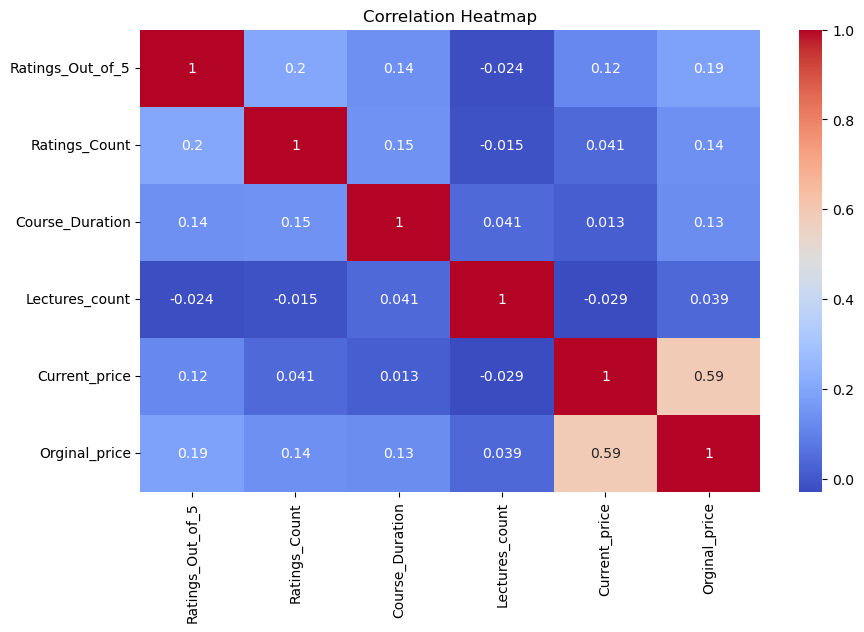

In [133]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### Interpretation : Lecture count and course duration are strongly positively correlated.

## Hypothesis Testing 

#### H0: Course duration and ratings are not significantly correlated.

#### H1: Course duration and ratings are significantly correlated.

In [140]:
from scipy.stats import pearsonr
corr, p_value = pearsonr(
    df['Course_Duration'],
    df['Ratings_Out_of_5']
)
print("Correlation:", corr)

print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0")

else:
    print("Fail to Reject H0")

Correlation: 0.13676609737285403
P-value: 2.393320951421609e-16
Reject H0


##  HYPOTHESIS 2 : Course Level vs Current Price (Based on boxplot/barplot)

#### H0: Mean course prices are equal across all course levels.

#### H1: At least one course level has a significantly different mean price.


Since:

categorical vs numerical
more than 2 categories

Use:

ANOVA Test

In [141]:
from scipy.stats import f_oneway

all_levels = df[df['Course_level']=='All Levels']['Current_price']

beginner = df[df['Course_level']=='Beginner']['Current_price']

intermediate = df[df['Course_level']=='Intermediate']['Current_price']

expert = df[df['Course_level']=='Expert']['Current_price']

f_stat, p_value = f_oneway(
    all_levels,
    beginner,
    intermediate,
    expert
)

print("F-statistic:", f_stat)

print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0")

else:
    print("Fail to Reject H0")

F-statistic: 8.724107677164836
P-value: 9.175466741297176e-06
Reject H0


## Interpretation : Differences are too small/inconsistent to confidently conclude that course level affects price.

## HYPOTHESIS 4 Lectures Count vs Ratings(Scatter Plot)

#### H0: Number of lectures has no significant relationship with ratings.
#### H1: Courses with more lectures tend to receive different ratings.

In [145]:
corr, p_value = pearsonr(
    df['Lectures_count'],
    df['Ratings_Count']
)
print("Correlation:", corr)

print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0")

else:
    print("Fail to Reject H0")

Correlation: -0.01509185666549878
P-value: 0.3677437481044272
Fail to Reject H0


## Interpretation : the number of lectures does not appear to meaningfully influence the number of ratings received by a course."